# Sistema de Login Biométrico Facial: Implementación y Evaluación
Este notebook permite visualizar, probar y evaluar de forma interactiva todas las etapas del pipeline en cascada diseñado en el proyecto.

In [1]:
import os
import sys
from pathlib import Path

# Añadir el directorio raíz al path para importar módulos de 'src'
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger

# Silenciar logs por defecto para mayor limpieza en el notebook
logger.remove()

# Importaciones Creadas
from src.models.face_login_system import FaceLoginSystem
from src.features.preprocessor import FacePreprocessingPipeline
from src.evaluation.metrics import BiometricBenchmark
from src.data.face_dataset import VerificationPairDataset

# Utilidad para mostrar imágenes cómodamente en Jupyter
def show_image(img_bgr, title="Imagen"):
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(4, 4))
        plt.imshow(img_rgb)
        plt.title(title)
        plt.axis('off')
        plt.show()

c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P5_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Inicialización del Pipeline en Cascada
Cargamos la configuración base `config.yaml`.

In [10]:
config_path = '../config/config.yaml'
db_path = '../models/notebook_embeddings.pkl.enc'
passphrase = 'contrasena'

system = FaceLoginSystem.from_config(
    config_path=config_path,
    passphrase=passphrase,
    db_path=db_path
)

print("\n[✔] Sistema inicializado")
print(f"-> Threshold Anti-Spoofing (Liveness): {system.liveness_detector.threshold}")
print(f"-> Threshold Similitud Coseno: {system.sim_threshold}")


[✔] Sistema inicializado
-> Threshold Anti-Spoofing (Liveness): 0.95
-> Threshold Similitud Coseno: 0.68


## 2. Flujo de Autenticación Paso a Paso (Debug Visual)
Usando una imagen concreta, podemos ver cómo actúan las fases MTCNN (alineación y recorte) y Antispoofing.

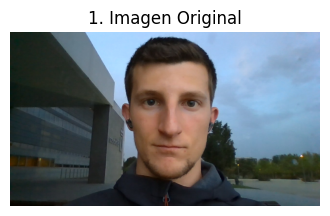

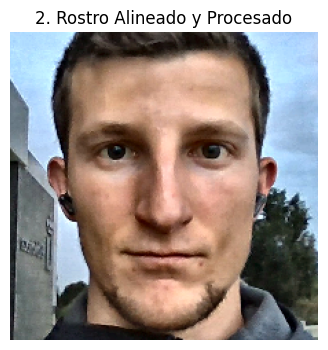

3. Anti-Spoofing -> Score liveness: 0.4452 | Pass?: False


In [12]:
sample_img_path = '../data/raw/diego/WIN_20260421_21_00_47_Pro.jpg'
img_bgr = cv2.imread(sample_img_path)

if img_bgr is not None:
    show_image(img_bgr, "1. Imagen Original")
    
    # Fases de Preprocesamiento:
    face_bgr, det = system.preproc_pipeline.run(img_bgr)
    show_image(face_bgr, "2. Rostro Alineado y Procesado")
    
    # Fase de Liveness:
    score, is_live = system.liveness_detector.predict(face_bgr)
    print(f"3. Anti-Spoofing -> Score liveness: {score:.4f} | Pass?: {is_live}")
else:
    print("Descomenta el bloque y apunta a una imagen real.")

## 3. Demostración de Flujo Completo (Registro / Verificación)

In [4]:
usuario_test = "diego_test"

#### 3.1 Registrar Usuario ####
# img_registro = cv2.imread('../data/raw/diego_reg.jpg')
# if img_registro is not None:
#     system.register(usuario_test, img_registro)
#     print(f"Usuarios actuales registrados: {system.list_users()}")

#### 3.2 Hacer Login con otra imagen ####
# img_login = cv2.imread('../data/raw/diego_login.jpg')
# if img_login is not None: 
#     resultado = system.authenticate(usuario_test, img_login)
#     
#     print("\n--- RESULTADO DE VERIFICACIÓN ---")
#     print(f"Status Final: {resultado.status.name}")
#     print(f"Mensaje:      {resultado.message}")
#     if resultado.similarity_score:
#         print(f"Score Similitud: {resultado.similarity_score:.4f}")

## 4. Benchmark de Extraer Embeddings
Realizamos un benchmark en bloque para medir la velocidad de extracción de características en hardware actual (CPU/GPU) usando múltiples imágenes.

In [5]:
import glob

def ejecutar_benchmark(carpeta_imagenes):
    rutas = glob.glob(os.path.join(carpeta_imagenes, '*.*'))
    imagenes = [cv2.imread(r) for r in rutas if cv2.imread(r) is not None]
    
    if not imagenes:
        print(f"No hay imágenes válidas en {carpeta_imagenes}")
        return
        
    print(f"Evaluando {len(imagenes)} imágenes...")
    resultados = system.embedder.benchmark(imagenes, min(50, len(imagenes)))
    
    for backend, metricas in resultados.items():
        print(f"\nBackend: {backend.upper()}\n" + "-"*20)
        for met, val in metricas.items():
            print(f"{met:<20}: {val:.4f} segs")

# ejecutar_benchmark('../data/raw/bench_faces/')

## 5. Evaluación Empírica: ROC, EER y Matriz de Pares
En base a un fichero `pairs.csv` previamente conformado, la clase `BiometricBenchmark` evalúa las métricas tradicionales de biometría.

In [6]:
def evaluar_sistema(csv_pares, carpeta_salida='../doc/evaluation'):
    if not os.path.exists(csv_pares):
        print(f"CSV '{csv_pares}' no encontrado. Se requiere generar el dataset intermedio.")
        return
        
    print("\n--- INICIANDO EVALUACIÓN DE PARES ---")
    dataset = VerificationPairDataset(csv_pares)
    evaluador = BiometricBenchmark(dataset, system)
    
    # Pasamos los thresholds de configuración
    reporte = evaluador.run(
        thresholds={'arcface': system.sim_threshold}, 
        output_dir=carpeta_salida
    )
    
    evaluador.save_report(reporte, carpeta_salida)
    print(f"\n¡Hecho! Las gráficas generadas y el informe se han guardado bajo: {carpeta_salida}")

# evaluar_sistema('../data/processed/pairs.csv')